# Team Value Over Time

Normalized **team power ranking** over time, one league per section — each shown two ways:

- **Normalized 1–99** (top chart): KTC's `/power-rankings/teams` scale, where the top team that week = 99 and everyone scales off it. Matches the live page (±1).
- **Adjusted value, raw** (bottom chart): the underlying `prProcessV` sum, *not* re-baselined each week — shows absolute roster strength over time (the 1–99 view pins the leader flat, which can look funky).

Both use the same metric: KTC's `prProcessV` depth adjustment **including draft picks** (the *Include Picks* / `hrdp=0` view), on **Superflex + TE‑Premium** values (SF Standard fallback before TEP existed, ~pre‑2025‑10).

In [1]:
import os, sys, importlib
# robust import: works whether the kernel cwd is the repo root or analysis/
for _d in [os.getcwd(), os.path.join(os.getcwd(), "analysis")]:
    if os.path.isfile(os.path.join(_d, "fantasy_lib.py")):
        if _d not in sys.path:
            sys.path.insert(0, _d)
        break
import polars as pl
import matplotlib.pyplot as plt
import fantasy_lib as F
importlib.reload(F)          # pick up edits without restarting the kernel
import warnings
warnings.filterwarnings("ignore", message=".*Sortedness.*")
print("fantasy_lib:", F.__file__)

fantasy_lib: C:\Users\simer\Coding Project\Fantasy Analysis\analysis\fantasy_lib.py


In [2]:
# --- load ownership ledger, dims, and the value lens ---
ledger = F.load_ledger()
franchises, _ = F.load_dims()
fr_meta = franchises.select("franchise_id", "league_lineage_id", "current_team_name", "roster_id")

player_values = F.load_player_values_blend(qb_format="SF")          # SF/TEP, Standard before TEP era
pick_values   = F.load_pick_values_round("ktc", "SF", "Standard")   # round-level KTC pick values

# weekly grid from the start of value coverage through the latest valuation date
START = max(ledger["valid_from"].min(), player_values["valuation_date"].min().isoformat())
TODAY = player_values["valuation_date"].max().isoformat()
dates = sorted(set(F.weekly_dates(START, TODAY) + [TODAY]))

# KTC power ranking WITH picks (hrdp=0), per (lineage, date): has both adj_total and power_index
power = (F.team_power_index(ledger, dates, player_values, fr_meta, pick_values=pick_values)
          .join(fr_meta.select("franchise_id", "current_team_name").unique(subset=["franchise_id"]),
                on="franchise_id", how="left"))


# trim each lineage's startup ramp: the first week holds a partial roster (startup draft
# still filling; picks are minted ~a week later -> 0 picks on day 1), which causes a fake
# week-1->2 spike. Start each lineage at its first week reaching >=95% of its steady-state
# (median) asset count.
_lin = fr_meta.select("franchise_id", "league_lineage_id").unique(subset=["franchise_id"])
_counts = (F._holdings_by_date(ledger, dates).join(_lin, on="franchise_id", how="left")
           .group_by("league_lineage_id", "date").agg(pl.len().alias("n")))
_starts = (_counts.join(_counts.group_by("league_lineage_id").agg(pl.col("n").median().alias("med")),
                        on="league_lineage_id")
           .filter(pl.col("n") >= 0.95 * pl.col("med"))
           .group_by("league_lineage_id").agg(pl.col("date").min().alias("_start")))
power = (power.join(_starts, on="league_lineage_id", how="left")
         .filter(pl.col("date") >= pl.col("_start")).drop("_start"))
LEAGUE_NAMES = {
    "730630605066371072":  "Stuck in High School",
    "1131624152349323264": "Football Guys of Indianapolis",
    "1061511485920354304": "Sigma Chi Dynasty League",
}
print(f"{len(dates)} weekly points {START} -> {TODAY} | "
      f"{power['franchise_id'].n_unique()} teams across {power['league_lineage_id'].n_unique()} leagues")

250 weekly points 2021-09-07 -> 2026-06-15 | 34 teams across 3 leagues


In [3]:
# metric: "power_index" (normalized 1-99) or "adj_total" (raw prProcessV sum)
_METRIC_LABEL = {"power_index": "Power index  (1-99, picks incl.)",
                 "adj_total":   "Adjusted value  (prProcessV sum, picks incl.)"}
_METRIC_TITLE = {"power_index": "normalized 1-99", "adj_total": "adjusted value (raw)"}

def plot_league(lineage_id, metric="power_index", ax=None):
    """One league over time on one axis. metric in {"power_index", "adj_total"}."""
    d = power.filter(pl.col("league_lineage_id") == lineage_id)
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 7))
    latest = (d.sort("date").group_by("current_team_name").agg(pl.col(metric).last())
              .sort(metric, descending=True))                      # legend ranked by latest value
    for team in latest["current_team_name"]:
        s = d.filter(pl.col("current_team_name") == team).sort("date")
        last = int(round(s[metric][-1]))
        label = f"{team} ({last:,})" if metric == "adj_total" else f"{team} ({last})"
        ax.plot(s["date"].to_list(), s[metric].to_list(), linewidth=1.8, label=label)
    ax.set_title(f"{LEAGUE_NAMES.get(lineage_id, lineage_id)} — {_METRIC_TITLE[metric]}",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel(_METRIC_LABEL[metric])
    if metric == "power_index":
        ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
    ax.tick_params(axis="x", rotation=45)
    return ax

def plot_league_both(lineage_id):
    """Both views stacked: normalized 1-99 (top) and raw adjusted value (bottom)."""
    fig, axes = plt.subplots(2, 1, figsize=(13, 13))
    plot_league(lineage_id, "power_index", ax=axes[0])
    plot_league(lineage_id, "adj_total",   ax=axes[1])
    fig.tight_layout()
    return fig

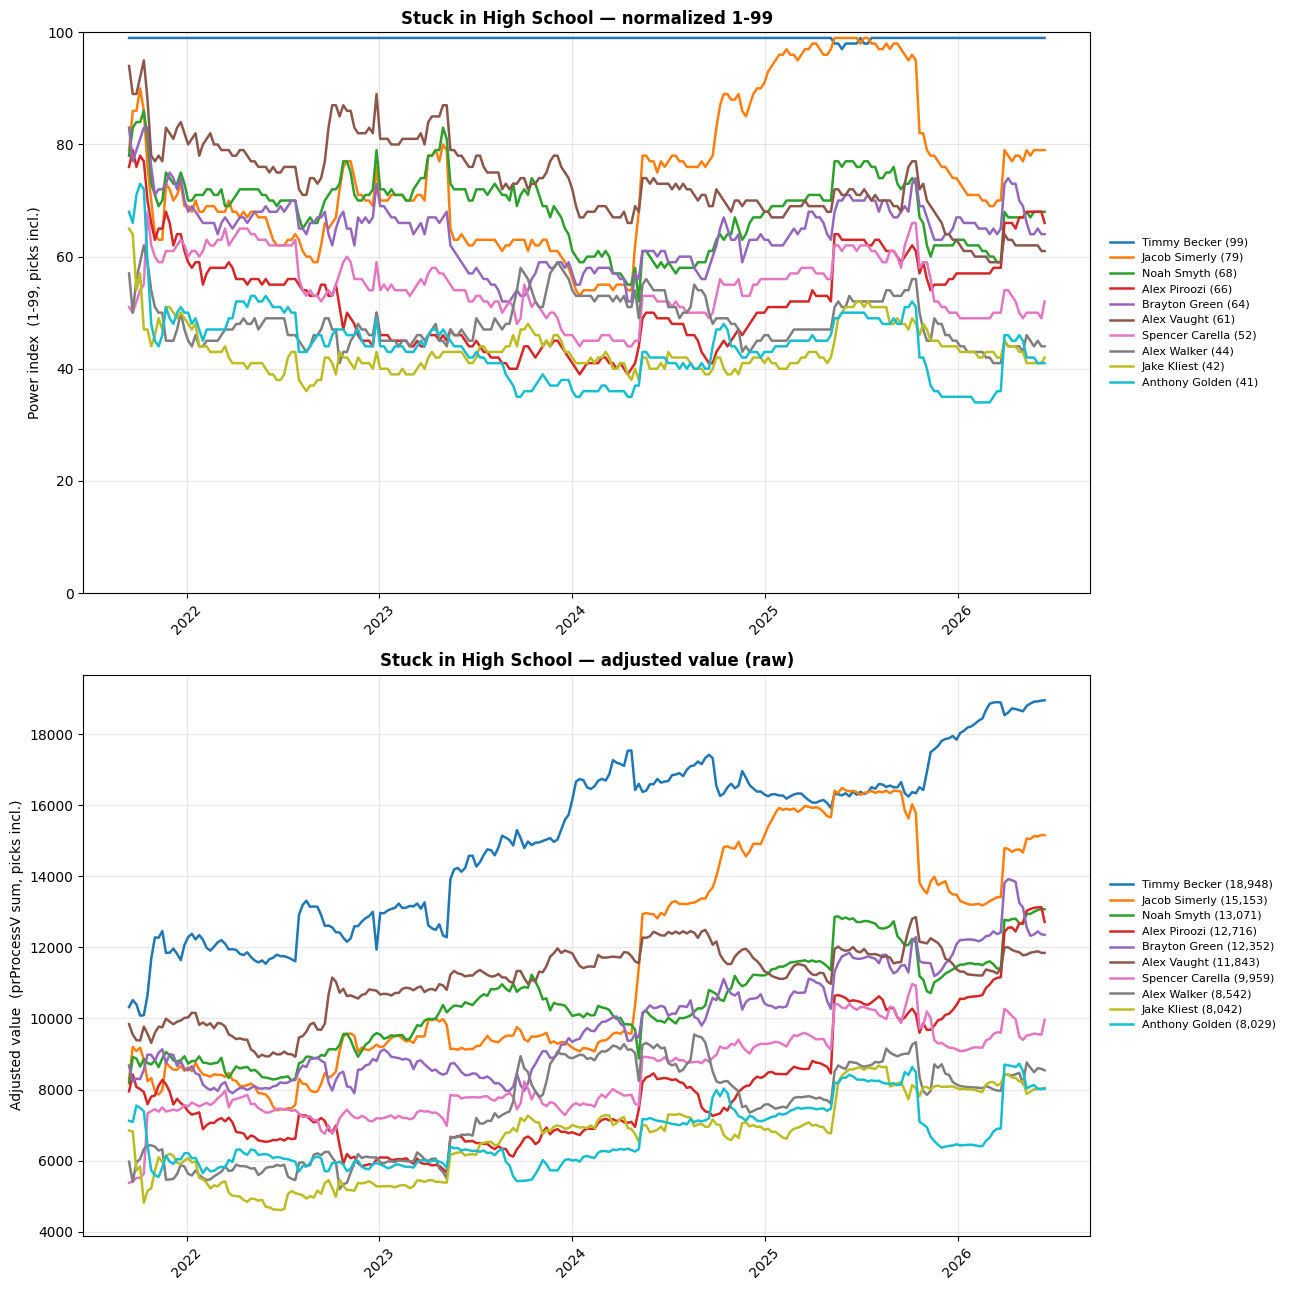

In [4]:
plot_league_both("730630605066371072")   # Stuck in High School
plt.show()

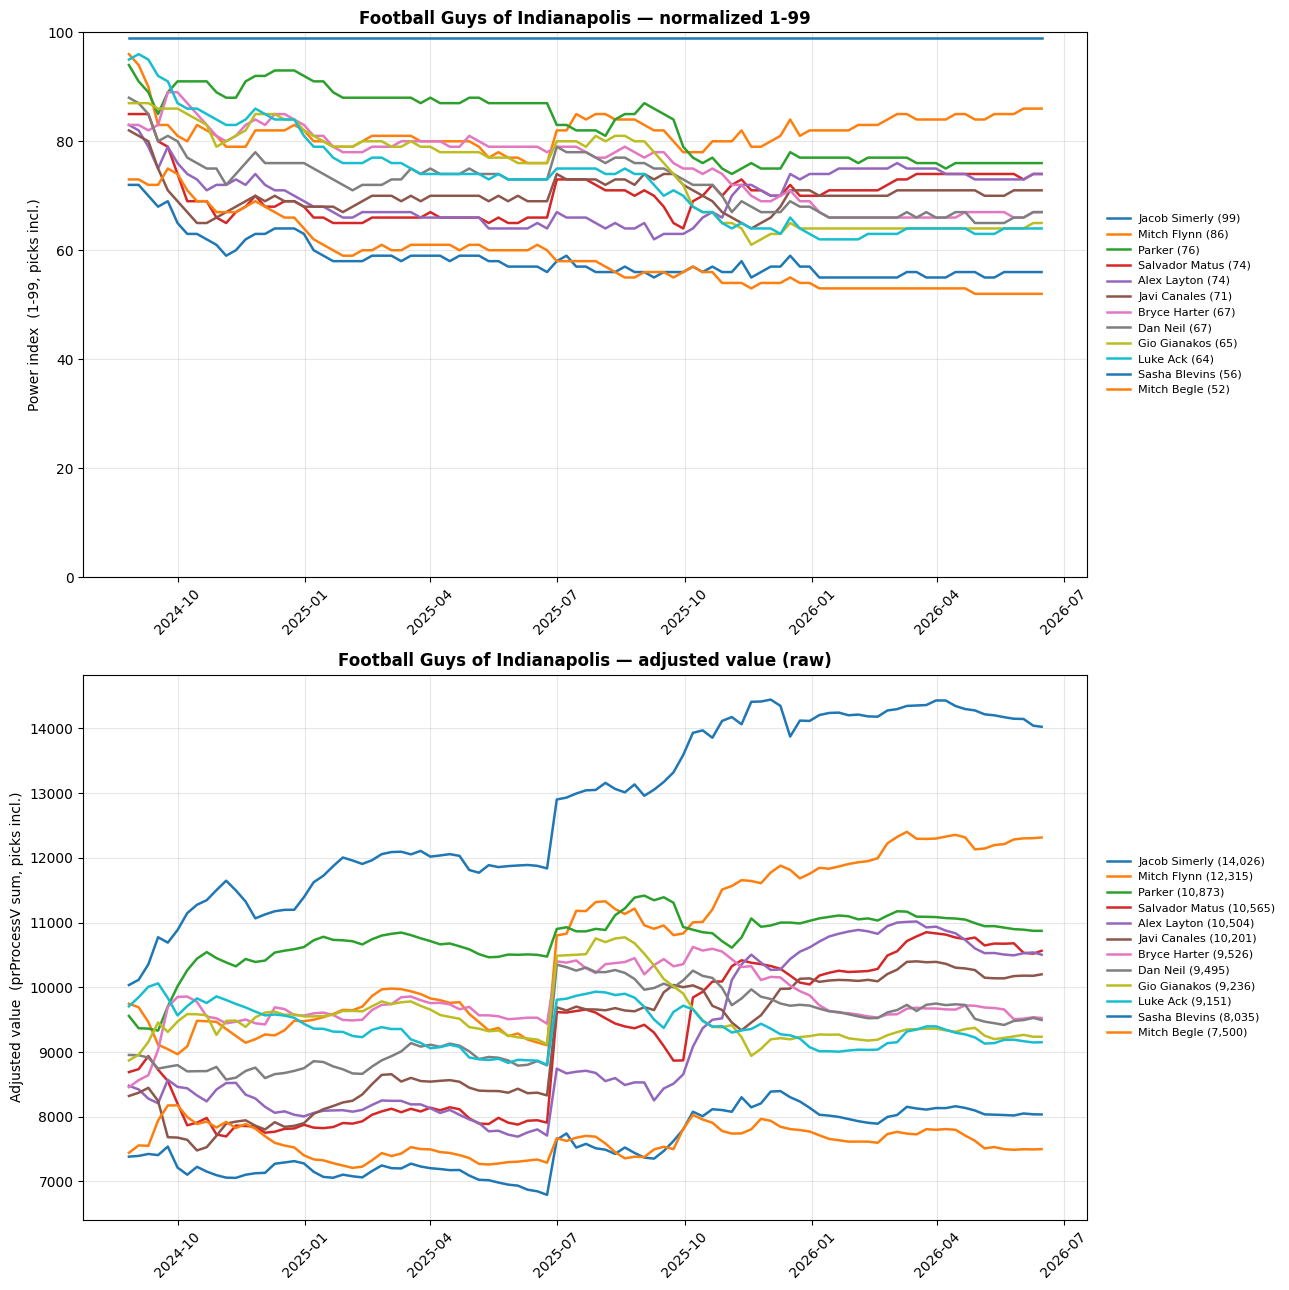

In [5]:
plot_league_both("1131624152349323264")  # Football Guys of Indianapolis
plt.show()

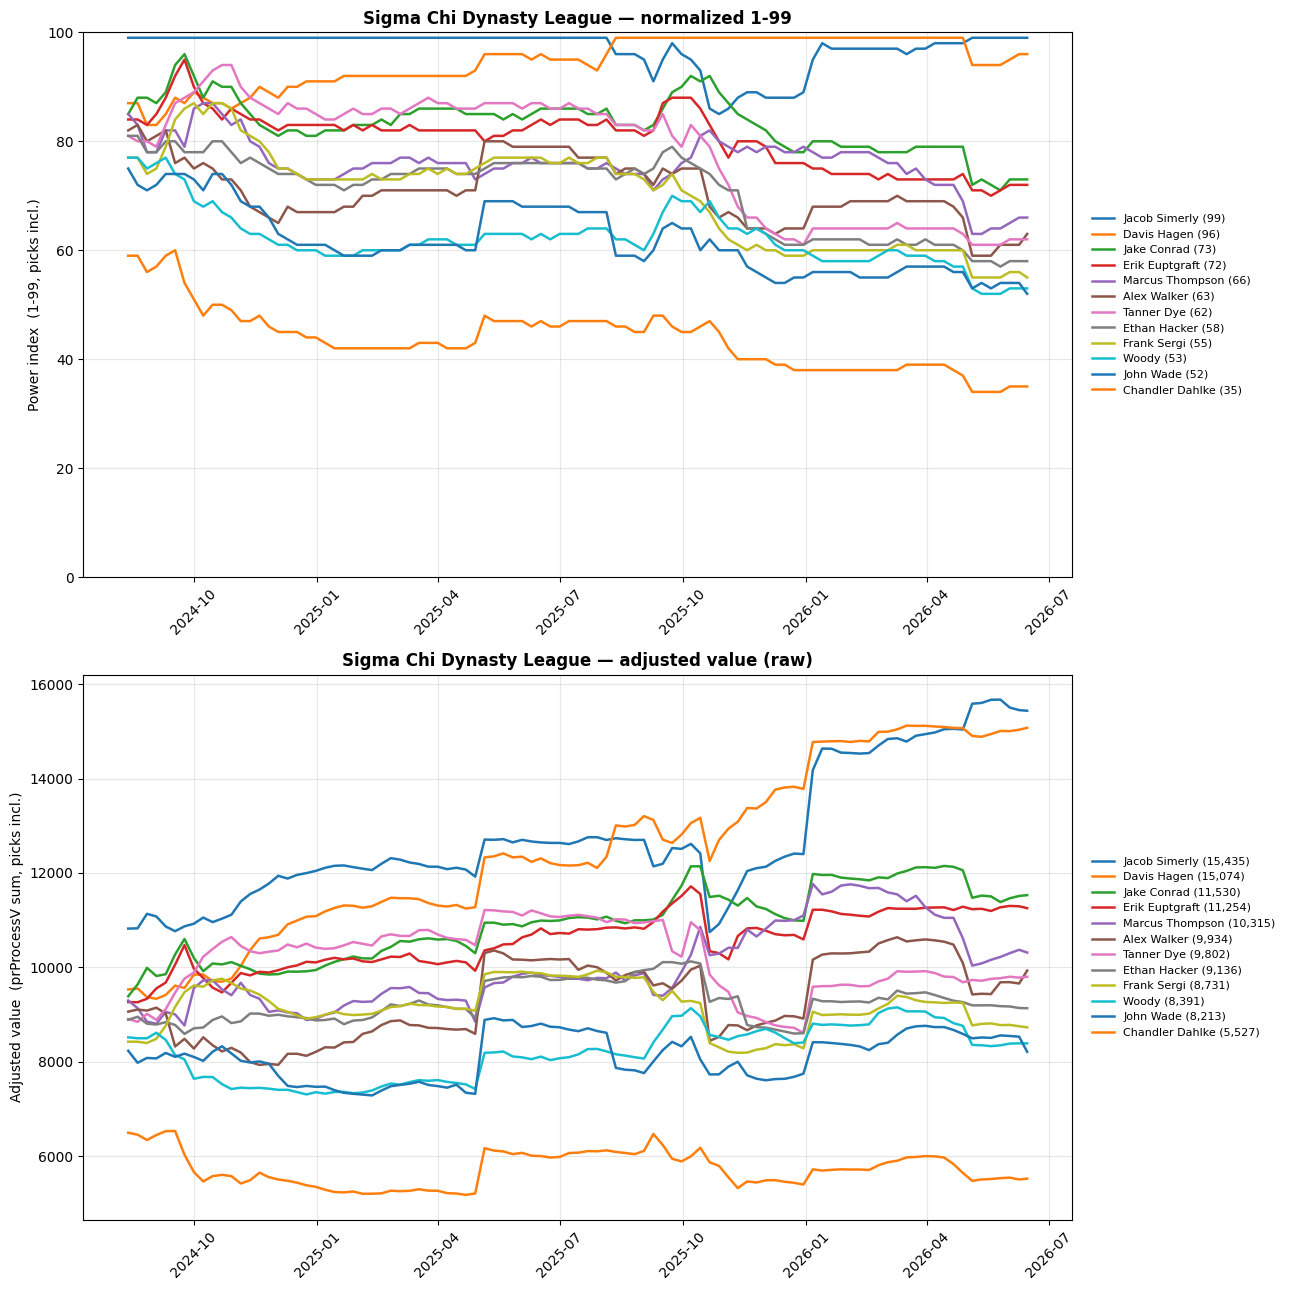

In [6]:
plot_league_both("1061511485920354304")  # Sigma Chi Dynasty League
plt.show()